In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
T_ML = {"li_bcc": 1.20, "al_fcc": 1.16, "ti_hcp": 1.16, "ge_cd": 1.32}

def plot_results(path: Path, exp_names: list[str]) -> None:
    plt.style.use("seaborn-v0_8-deep")
    plt.rcParams["font.family"] = "Segoe UI"

    data = pd.read_csv(path, index_col=0)

    nrows = (len(exp_names) + 1) // 2
    ncols = min(len(exp_names), 2)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    if len(exp_names) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    fig.suptitle("MD Benchmarking Results", fontsize=16, fontstyle="italic")

    for i, exp_name in enumerate(exp_names):
        ax = axes[i]

        ax.plot(data.index, data[exp_name], "o-", markersize=3, label="MACE")

        ax.set_title(exp_name)
        ax.set_ylabel("Accuracy")
        ax.set_xlabel("T / Tm")
        ax.set_xlim(0.0, 1.64)
        ax.set_ylim(0.75, 1.01)
        ax.axvline(x=1.0, color="darkgray", linestyle="--", alpha=0.7, label="T_m")
        ax.axvline(x=T_ML[exp_name], color="red", linestyle="--", alpha=0.7,
                   label=f"T_ml = {T_ML[exp_name]}")
        ax.legend(fontsize=8, loc="lower left")

    for j in range(len(exp_names), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

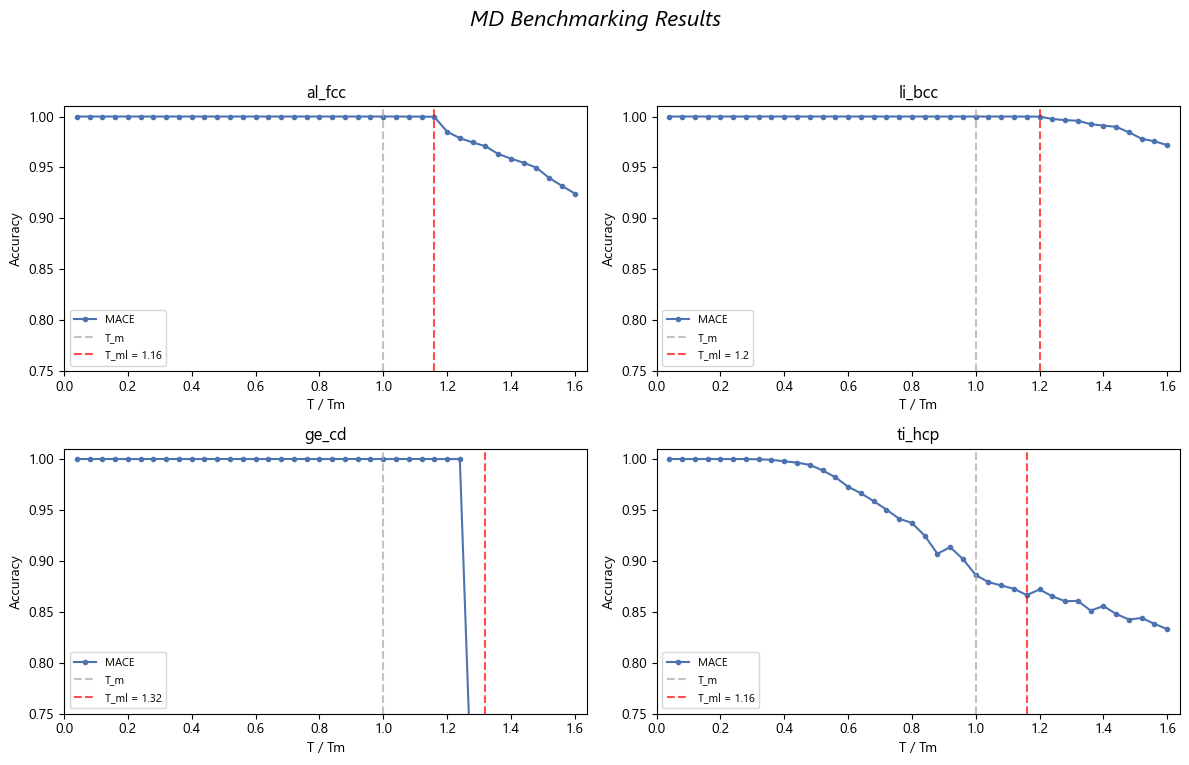

In [ ]:
plot_results(Path("results.csv"), ["al_fcc", "li_bcc", "ge_cd", "ti_hcp"])